In [1]:
from multiprocessing import current_process
from netgen.meshing import *
from netgen.csg import *
from netgen.occ import *
from ngsolve import *
from ngsolve.fem import MixedFE
from ngsolve.webgui import Draw
from netgen.webgui import Draw as DrawGeo
import math
from numpy import *
import scipy.sparse as sp
import matplotlib.pylab as plt
from scipy.io import savemat
import scipy.sparse as sp

import os, sys
sys.path.append('../../ICCG/JP-MARs/SparseSolv')
import SparseSolvPy

In [2]:
h=0.01
r=0.01
conductor = Cylinder((0,0,0), Z, r=r, h=h)
conductor.maxh=r/10.
Draw(conductor)

conductor.faces.name="conductorBND"
conductor.faces.Max(Z).name="out"
conductor.faces.Min(Z).name="in"
conductor.mat("sig")
crosssection = conductor.faces.Max(Z).mass
print(crosssection)

geo =OCCGeometry(conductor)
with TaskManager():
#    mesh = Mesh(geo.GenerateMesh(maxh=0.005)).Curve(3)
#    mesh = Mesh(geo.GenerateMesh(maxh=0.001)).Curve(100)  
#    mesh = Mesh(geo.GenerateMesh()).Curve(0) 
    mesh = Mesh(geo.GenerateMesh(maxh=0.001)).Curve(3)
#    mesh = Mesh(geo.GenerateMesh(meshsize.very_coarse)).Curve(5)   
Draw (mesh)

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': 3…

0.0003141592653589792


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

BaseWebGuiScene

#nv= 2971
#nedge= 17754
#nface= 28197
#ne= 13413
262683
HcurlA_ndof = 17754
HcurlT_ndof = 17754
ndof = 35508
Dof= 17754    matrix size= 107076.0


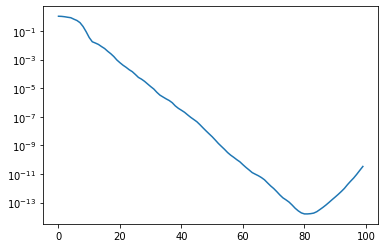

min: 1.618186601948934e-14
結果のノルム: 4.2857214141209324e-14
norm= 4.2857214141209324e-14
R_theory[ 0 ]: 0.3183098861837906
       R[ 0 ]: 0.31828467613480504
     R_err[ 0 ]: 7.919970468959743e-05
1 -stage
Dof= 13641    matrix size= 81521.0


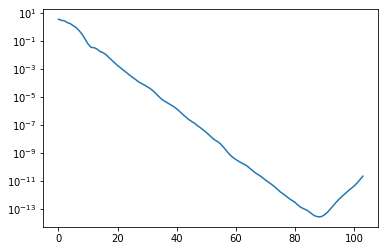

min: 2.64388800557433e-14
結果のノルム: 1.0799204454912818e-13
L_theory[ 1 ]: 4.9999999999999996e-06
       L[ 1 ]: 4.987912539094637e-06
     L_err[ 1 ]: 0.002417492181072456
Dof= 17754    matrix size= 107076.0


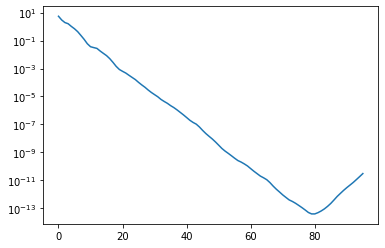

min: 3.81691664225365e-14
結果のノルム: 1.125181135482347e-13
norm= 1.125181135482347e-13
R_theory[ 2 ]: 0.9549296585513718
       R[ 2 ]: 0.9677629073966221
     R_err[ 2 ]: 0.01343894676464266
2 -stage
Dof= 13641    matrix size= 81521.0


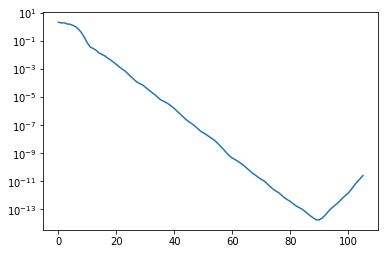

min: 1.8015510087692917e-14
結果のノルム: 7.68198295107159e-14
L_theory[ 3 ]: 2.4999999999999998e-06
       L[ 3 ]: 2.476014447094857e-06
     L_err[ 2 ]: 0.009594221162057036
Dof= 17754    matrix size= 107076.0


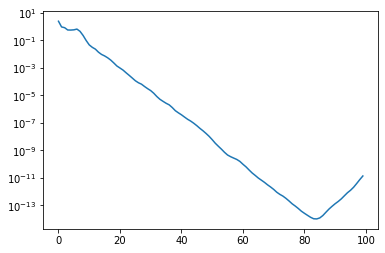

min: 1.0302053739911064e-14
結果のノルム: 3.4114631289177436e-14
norm= 3.4114631289177436e-14
R_theory[ 4 ]: 1.591549430918953
       R[ 4 ]: 1.6555561320444476
     R_err[ 4 ]: 0.040216596407274256
A1_A3_InnerProduct -1.2995303567030897e-17
B1_H3_InnerProduct -3.024332015624003e-10
J2_J4_InnerProduct -150.3047585970574
J2_E4_InnerProduct -0.00015030475859689635
R2 0.9677629073966219


In [3]:
edges_no=mesh.nedge
faces_no=mesh.nface
elements_no=mesh.nv
calcd_ndof = (mesh.nedge*3)+( mesh.nface*6)+( mesh.ne*3)
print('#nv=', mesh.nv)
print('#nedge=', mesh.nedge)
print('#nface=', mesh.nface)
print('#ne=', mesh.ne)
print(calcd_ndof)
order=1
fesA = HCurl(mesh, order=order, nograds=True, dirichlet="in|out|conductorBND", complex=False)
fesT = HCurl(mesh, order=order, nograds=True, complex=False)
print ("HcurlA_ndof =", fesA.ndof)
print ("HcurlT_ndof =", fesT.ndof)
print ("ndof =", fesA.ndof+fesT.ndof)

A, N =fesA.TnT()
T, W =fesT.TnT()

c = 299792458.
mu = 4*math.pi*1e-7
eps = 1/(c*c*mu)
sigma=1e6

Rn=[]
Ln=[]
log1min=[]
ndof=[]
nstage=[]

Es=(0,0,1)
n =specialcf.normal(mesh.dim)
a = BilinearForm(fesT)
a += 1/sigma*curl(T)*curl(W)*dx
f = LinearForm(fesT)
f += -Cross(Es, W.Trace())*n * ds("conductorBND")
with TaskManager():
    a.Assemble()
    f.Assemble()

gfT = GridFunction(fesT)

mat = sp.csr_matrix (a.mat.CSR())
#print(mat)
Acut = mat[:,fesT.FreeDofs()][fesT.FreeDofs(),:]
fcut = array(f.vec.FV())[fesT.FreeDofs()]
ucut = array(f.vec.FV(), copy=True)[fesT.FreeDofs()]

rows, cols = Acut.nonzero()
vals = Acut[rows, cols]
vals = ravel(vals)
dim=fcut.size
size= (len(rows)-dim)/2-dim
print('Dof=',dim, '   matrix size=', size)

mat = SparseSolvPy.SparseMat(len(rows), rows, cols, vals)
solver = SparseSolvPy.MatSolvers()
solver.setSaveBest(True)
solver.setSaveLog(True)
solver.setDiagScale(False)
solver.setDirvegeType(1)
solver.setBadDivCount(10)
solver.setBadDivVal(10.0)
tol=1.e-16
max_iter=200
solver.solveICCG_py(len(fcut), tol, max_iter, 1.1, mat, fcut, ucut, True)

log1 = solver.getResidualLog_py()
#print(log1)

plt.plot(range(len(log1)), log1)    
plt.yscale('log')
plt.show(block=False)  

array(gfT.vec.FV(), copy=False)[fesT.FreeDofs()] = ucut
print("min:", min(log1))
#log1min.append(min(log1))

result = Acut.dot(ucut) - fcut
norm = linalg.norm(result)/linalg.norm(fcut)
print("結果のノルム:", norm)

result = Acut.dot(ucut) - fcut
norm = linalg.norm(result)/linalg.norm(fcut)
print("norm=", norm)

J =curl(gfT)
E= 1./sigma*J

nStage=0
R = 1/Integrate(sigma*E*E*dx, mesh)
Rn.append(R)
R_theory = (2*nStage+1)/(pi*r*r*sigma*h)
print("R_theory[",2*nStage,"]:", R_theory)
print("       R[",2*nStage,"]:", R)
R_err = abs(R - R_theory)/abs(R_theory)
print("     R_err[",2*nStage,"]:",R_err) 

for nStage in range(2):
    print(nStage+1, "-stage")
    nstage.append(nStage+1)


    a = BilinearForm(fesA)
    a += 1/mu*curl(A)*curl(N)*dx
    f = LinearForm(fesA)
    f += N*(R*J) * dx
    with TaskManager():
        a.Assemble()
        f.Assemble()

    gfA = GridFunction(fesA)

    mat = sp.csr_matrix (a.mat.CSR())
    #print(A)
    Acut = mat[:,fesA.FreeDofs()][fesA.FreeDofs(),:]
    fcut = array(f.vec.FV())[fesA.FreeDofs()]
    ucut = array(f.vec.FV(), copy=True)[fesA.FreeDofs()]

    rows, cols = Acut.nonzero()
    vals = Acut[rows, cols]
    vals = ravel(vals)
    dim=fcut.size
    size= (len(rows)-dim)/2-dim
    print('Dof=',dim, '   matrix size=', size)
    
    mat = SparseSolvPy.SparseMat(len(rows), rows, cols, vals)

    solver = SparseSolvPy.MatSolvers()
    solver.setSaveBest(True)
    solver.setSaveLog(True)
    solver.setDiagScale(False)
    solver.setDirvegeType(1)
    solver.setBadDivCount(10)
    solver.setBadDivVal(10.0)
    tol=1.e-16
    max_iter=200
    solver.solveICCG_py(len(fcut), tol, max_iter, 1.1, mat, fcut, ucut, True)
    
    
    log1 = solver.getResidualLog_py()
    #print(log1)

    plt.plot(range(len(log1)), log1)    
    plt.yscale('log')
    plt.show(block=False)  
    
    array(gfA.vec.FV(), copy=False)[fesA.FreeDofs()] = ucut
    print("min:", min(log1))
    #log1min.append(min(log1))

    result = Acut.dot(ucut) - fcut
    norm = linalg.norm(result)/linalg.norm(fcut)
    print("結果のノルム:", norm)
    
    if nStage ==0:
        Apot=gfA
        A1 = Apot
        B= curl(gfA)
        B1 = B
    else:
        Apot =Apot + gfA
        A3 = Apot
        B = B+curl(gfA)
        B3 = B
        
    #B=curl(Apot)
    L = Integrate(B*B/mu*dx, mesh)
    Ln.append(L)
    L_theory = (mu)/(4*2*(nStage+1)*pi*h)
    print("L_theory[",2*nStage+1,"]:", L_theory)
    print("       L[",2*nStage+1,"]:", L)
    L_err = abs(L - L_theory)/abs(L_theory)
    print("     L_err[",nStage+1,"]:",L_err) 
    
    a = BilinearForm(fesT)
    a += 1./sigma*curl(T)*curl(W)*dx
    f = LinearForm(fesT)
    f += W*(-B/L) * dx
    with TaskManager():
        a.Assemble()
        f.Assemble()

    gfT = GridFunction(fesT)

    mat = sp.csr_matrix (a.mat.CSR())
    #print(mat)
    Acut = mat[:,fesT.FreeDofs()][fesT.FreeDofs(),:]
    fcut = array(f.vec.FV())[fesT.FreeDofs()]
    ucut = array(f.vec.FV(), copy=True)[fesT.FreeDofs()]

    rows, cols = Acut.nonzero()
    vals = Acut[rows, cols]
    vals = ravel(vals)
    dim=fcut.size
    size= (len(rows)-dim)/2-dim
    print('Dof=',dim, '   matrix size=', size)

    mat = SparseSolvPy.SparseMat(len(rows), rows, cols, vals)
    solver = SparseSolvPy.MatSolvers()
    solver.setSaveBest(True)
    solver.setSaveLog(True)
    solver.setDiagScale(False)
    solver.setDirvegeType(1)
    solver.setBadDivCount(10)
    solver.setBadDivVal(10.0)
    tol=1.e-16
    max_iter=200
    solver.solveICCG_py(len(fcut), tol, max_iter, 1.1, mat, fcut, ucut, True)

    log1 = solver.getResidualLog_py()
    #print(log1)

    plt.plot(range(len(log1)), log1)    
    plt.yscale('log')
    plt.show(block=False)  

    array(gfT.vec.FV(), copy=False)[fesT.FreeDofs()] = ucut
    print("min:", min(log1))
#log1min.append(min(log1))

    result = Acut.dot(ucut) - fcut
    norm = linalg.norm(result)/linalg.norm(fcut)
    print("結果のノルム:", norm)

    result = Acut.dot(ucut) - fcut
    norm = linalg.norm(result)/linalg.norm(fcut)
    print("norm=", norm)

    J=J+curl(gfT)
    E=J/sigma

    if nStage ==0:
        J2 = J
    else:
        J4 = J
    
    
    R = 1/Integrate(sigma*E*E*dx, mesh)
    
    if nStage<10-1:
        Rn.append(R)
        
    R_theory = (2*nStage+3)/(pi*r*r*sigma*h)
    print("R_theory[",2*nStage+2,"]:", R_theory)
    print("       R[",2*nStage+2,"]:", R)
    R_err = abs(R - R_theory)/abs(R_theory)
    print("     R_err[",2*nStage+2,"]:",R_err) 

data = {'Rn': Rn, 'Ln': Ln}
FileName = f"AT_{order}.mat"  
savemat(FileName,data)

print("A1_A3_InnerProduct", Integrate(InnerProduct(A1, A3), mesh))
print("B1_H3_InnerProduct", Integrate(InnerProduct(B1, B3/mu), mesh))
print("J2_J4_InnerProduct", Integrate(InnerProduct(J2, J4), mesh))
print("J2_E4_InnerProduct", Integrate(InnerProduct(J2, J4)/sigma, mesh))
print("R2", (1/Integrate(J2*J2/sigma, mesh)))